"\nfig = plt.figure(figsize = (8,8))\nax = fig.add_subplot (1,1,1)\nax.set_xlabel('Principal Component 1', fontsize = 15)\nax.set_ylabel('Principal Component 2', fontsize = 15)\nax.set_title('PCA_Macrophage', fontsize = 20)\n\ntargets = ['M0', 'M1', 'M2']\ncolors = ['r', 'g', 'b']\nfor target, color in zip(targets,colors):\n    indicesToKeep = finalDf['group'] == target\n    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']\n               , finalDf.loc[indicesToKeep, 'principal component 2']\n               , c = color\n               , s = 30)\n    \n    ax.legend(targets)\n    ax.grid()\npca.explained_variance_ratio_\n\nplt.savefig('PCA Macrophage.png')\n"

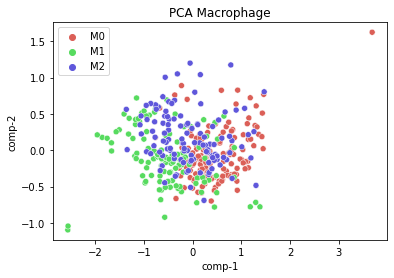

In [16]:
#PCA 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 
from sklearn import svm
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, OneHotEncoder 

#read the data
data = pd.read_excel('Macrophage_Visualization.xlsx')
#data.head(50)

X_features = data.iloc[:, 1:1301]
y_label = data.iloc[:,0]


#convert the features into the 2 top features
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(X_features)
#principalDf = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
#principalDf.head(5)
#data[['group']].head()
#finalDf = pd.concat([principalDf, data[['group']]], axis = 1)

df = pd.DataFrame()
df["y"] = y_label
df["comp-1"] = principalComponents[:,0]
df["comp-2"] = principalComponents[:,1]

scatter_plot = sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                palette=sns.color_palette("hls", 3),
                data=df).set(title="PCA Macrophage") 
 
plt.savefig('PCA Macrophage.png')




'''
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot (1,1,1)
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('PCA_Macrophage', fontsize = 20)

targets = ['M0', 'M1', 'M2']
colors = ['r', 'g', 'b']
for target, color in zip(targets,colors):
    indicesToKeep = finalDf['group'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , c = color
               , s = 30)
    
    ax.legend(targets)
    ax.grid()
pca.explained_variance_ratio_

plt.savefig('PCA Macrophage.png')
'''

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 389 samples in 0.001s...
[t-SNE] Computed neighbors for 389 samples in 0.008s...
[t-SNE] Computed conditional probabilities for sample 389 / 389
[t-SNE] Mean sigma: 0.343954
[t-SNE] KL divergence after 250 iterations with early exaggeration: 86.426758
[t-SNE] KL divergence after 1000 iterations: 0.975241


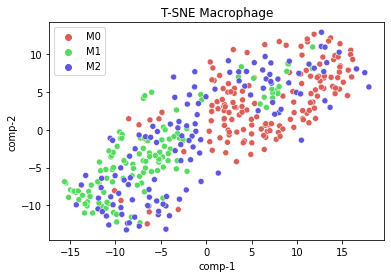

In [13]:
#t-SNE
from sklearn.manifold import TSNE
from numpy import reshape
import seaborn as sns

tsne = TSNE(n_components=2, verbose=1, random_state=123)
z = tsne.fit_transform(X_features)

df = pd.DataFrame()
df["y"] = y_label
df["comp-1"] = z[:,0]
df["comp-2"] = z[:,1]

scatter_plot = sns.scatterplot(x="comp-1", y="comp-2", hue=df.y.tolist(),
                palette=sns.color_palette("hls", 3),
                data=df).set(title="T-SNE Macrophage") 
 
plt.savefig('T-SNE Macrophage.png')

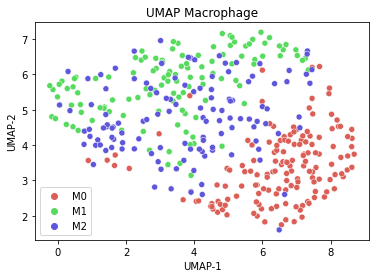

In [15]:
#UMAP
from numpy import reshape
import seaborn as sns

import umap
import umap.plot

#mapper = umap.UMAP().fit(X_features)
#umap.plot.points(mapper, labels=y_label)
embedding = umap.UMAP(n_neighbors=5,
                      min_dist=0.3,
                      metric='correlation').fit_transform(X_features)

result = pd.DataFrame()
result["y"] = y_label
result["UMAP-1"] = embedding[:,0]
result["UMAP-2"] = embedding[:,1]

sns.scatterplot(x="UMAP-1", y="UMAP-2", hue=result.y.tolist(),
                palette=sns.color_palette("hls", 3),
                data=result).set(title="UMAP Macrophage") 

plt.savefig('UMAP Macrophage.png')